In [1]:
from src.backend import TorchBackend
from src.kvector import compute_k0xy, compute_Kxy
from src.geometry import Rectangle, Bitmap, Canvas, VectorObject
from src.layer import Layer

from tests.backend import test_torch_backend_full
from tests.kvector import test_k0xy_full, test_Kxy_full
from tests.geometry import run_all_geometry_tests
import torch

import matplotlib.pyplot as plt
test_k0xy_full()
test_Kxy_full()
run_all_geometry_tests()

✓ full kvector test passed.
✓ full Kxy test passed.
FFT vs analytic RMSE: 0.0006081252346614848
All geometry tests passed.


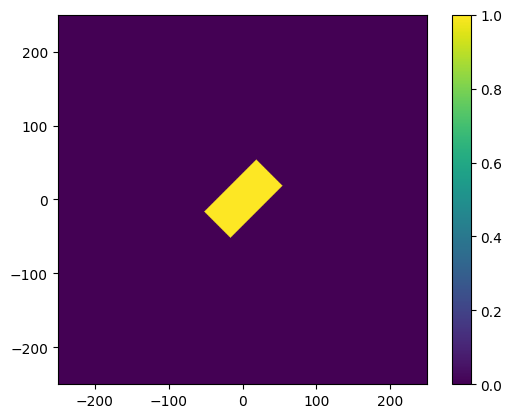

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
backend = TorchBackend(device=device, dtype=dtype)

period = (500.0, 500.0)
grid = (501, 501)
canv = Canvas(period, grid)
epsilon = torch.nn.Parameter(torch.tensor([2, 3, 4, 5]) + 0.1j, requires_grad=True)  # (B,)
center = torch.nn.Parameter(torch.tensor([0.0, 0.0]), requires_grad=True)
size = torch.nn.Parameter(torch.tensor([100.0, 50.0]), requires_grad=True)
angle = torch.nn.Parameter(torch.tensor(45.0*torch.pi/180), requires_grad=True)
rect = Rectangle(backend, 
                 canvas=canv,
                 center=center, 
                 size=size, 
                 epsilon=epsilon, 
                 angle=angle,
                 soft_mask=False)
epsilon_bg = torch.nn.Parameter(torch.tensor(1.0 + 0.0j), requires_grad=True)
layer = Layer(objects=rect, thickness=300.0, epsilon_bg=epsilon_bg)
plt.imshow(layer.bitmap.detach().cpu().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.colorbar()
plt.show()

In [13]:
layer.epsilon_mn(M=1, N=1, use_closed_form=False)[0]

tensor([[ 0.0174+0.0017j, -0.0191-0.0019j,  0.0193+0.0019j],
        [-0.0191-0.0019j,  1.0199+0.0020j, -0.0191-0.0019j],
        [ 0.0193+0.0019j, -0.0191-0.0019j,  0.0174+0.0017j]], device='cuda:0',
       grad_fn=<SelectBackward0>)

In [14]:
layer.epsilon_mn(M=1, N=1, use_closed_form=True)[0]

tensor([[ 0.0175+0.0017j, -0.0192-0.0019j,  0.0193+0.0019j],
        [-0.0192-0.0019j,  1.0200+0.0020j, -0.0192-0.0019j],
        [ 0.0193+0.0019j, -0.0192-0.0019j,  0.0175+0.0017j]], device='cuda:0',
       grad_fn=<SelectBackward0>)

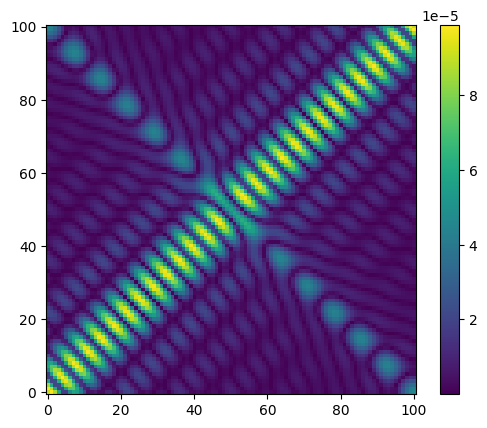

In [15]:
plt.imshow((layer.epsilon_mn(M=50, N=50, use_closed_form=False)[0] - layer.epsilon_mn(M=50, N=50, use_closed_form=True)[0]).abs().detach().cpu().T, origin='lower')
plt.colorbar()

In [16]:
print(epsilon.grad)
print(center.grad)
print(size.grad)
print(angle.grad)
print(epsilon_bg.grad)

None
None
None
None
None


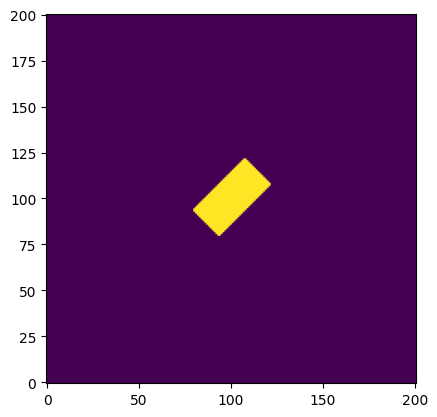

In [5]:
bitmap_im = rect.bitmap.cpu()
bitmap_new = torch.nn.Parameter(backend.asarray(bitmap_im.clone()), requires_grad=True)
epsilon = torch.nn.Parameter(torch.tensor([2, 3, 4, 5]) + 0.1j, requires_grad=True)  # (B,)
mu = torch.nn.Parameter(torch.tensor([2, 3, 24, 5]) + 0.1j, requires_grad=True)  # (B,)
epsilon_bg = torch.nn.Parameter(torch.tensor(1.0) + 0.0j, requires_grad=True)
mu_bg = torch.nn.Parameter(torch.tensor([1.0, 2.0, 3.0, 4.0]) + 0.0j, requires_grad=True)

bitmap = Bitmap(backend, 
                canv, 
                bitmap=bitmap_new, 
                epsilon=epsilon,
                mu=mu)

bitmap.epsilon_xy(epsilon_bg=epsilon_bg).abs().sum().backward(retain_graph=True)
bitmap.mu_xy(mu_bg=mu_bg).abs().sum().backward()

plt.imshow(bitmap.bitmap.detach().cpu().T, origin='lower')


In [8]:
print(f"Gradient w.r.t. bitmap: {bitmap_new.grad}")
print(f"Gradient w.r.t. epsilon: {epsilon.grad}")
print(f"Gradient w.r.t. mu: {mu.grad}")

Gradient w.r.t. bitmap: tensor([[34., 34., 34.,  ..., 34., 34., 34.],
        [34., 34., 34.,  ..., 34., 34., 34.],
        [34., 34., 34.,  ..., 34., 34., 34.],
        ...,
        [34., 34., 34.,  ..., 34., 34., 34.],
        [34., 34., 34.,  ..., 34., 34., 34.],
        [34., 34., 34.,  ..., 34., 34., 34.]], device='cuda:0')
Gradient w.r.t. epsilon: tensor([2118.3538+105.9177j, 2119.8228+70.6608j, 2120.3374+53.0084j,
        2120.5757+42.4115j])
Gradient w.r.t. mu: tensor([2118.3538+105.9177j, 2119.8228+70.6608j, 2120.9817+8.8374j,
        2120.5757+42.4115j])
